##**Loading Dataset**

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/emmarex/plantdisease")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: saimaghonigadepally
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease


100%|██████████| 658M/658M [00:06<00:00, 101MB/s]


##**Import Libraries**

In [ ]:
import pandas as pd

In [ ]:
import torch
import numpy as np
from torch import nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Dataset, Subset
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Number of total classes: 15
Tomato_Leaf_Mold
256
256


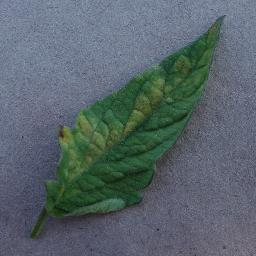

In [ ]:
path = "/content/plantdisease/PlantVillage"

classes = [name for name in os.listdir(path) if os.path.isdir(os.path.join(path, name))]

class_name = random.choice(classes)
class_path = os.path.join(path, class_name)
img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

img = Image.open(img_path)

print(f"Number of total classes: {len(classes)}")
print(class_name)
print(img.height)
print(img.width)

img

##**Preprocess Image**

In [ ]:
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ToTensor()
])

In [ ]:
def visualize_transform(img_path, transform):
    img = Image.open(img_path)
    print(img)
    transformed_img = transform(img)
    print(transformed_img)
    if isinstance(transformed_img, torch.Tensor):
      transformed_img = transforms.ToPILImage()(transformed_img)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(transformed_img)
    axes[1].set_title("Transformed")
    axes[1].axis("off")

    plt.show()

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256 at 0x7F0D9F776090>
tensor([[[0.6941, 0.6824, 0.6667,  ..., 0.6980, 0.6941, 0.6941],
         [0.6824, 0.6784, 0.6745,  ..., 0.6745, 0.6667, 0.6706],
         [0.6706, 0.6745, 0.6784,  ..., 0.6863, 0.6824, 0.6863],
         ...,
         [0.6039, 0.5961, 0.5608,  ..., 0.6471, 0.6392, 0.6471],
         [0.5490, 0.5804, 0.5961,  ..., 0.6549, 0.6471, 0.6627],
         [0.6000, 0.6039, 0.6039,  ..., 0.6588, 0.6549, 0.6745]],

        [[0.6431, 0.6314, 0.6157,  ..., 0.6510, 0.6471, 0.6471],
         [0.6314, 0.6275, 0.6235,  ..., 0.6275, 0.6196, 0.6235],
         [0.6196, 0.6235, 0.6275,  ..., 0.6392, 0.6353, 0.6392],
         ...,
         [0.5216, 0.5137, 0.4784,  ..., 0.5686, 0.5608, 0.5686],
         [0.4667, 0.4980, 0.5137,  ..., 0.5765, 0.5686, 0.5843],
         [0.5176, 0.5216, 0.5216,  ..., 0.5804, 0.5765, 0.5961]],

        [[0.6706, 0.6588, 0.6431,  ..., 0.6902, 0.6863, 0.6863],
         [0.6588, 0.6549, 0.6510,  ..., 0

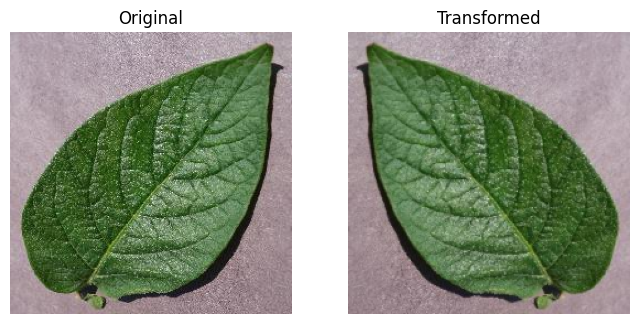

In [ ]:
class_name = random.choice(classes)
class_path = os.path.join(path, class_name)
img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

visualize_transform(img_path, data_transform)

In [ ]:
full_dataset = datasets.ImageFolder(root=path, transform=None)
full_dataset

Dataset ImageFolder
    Number of datapoints: 20638
    Root location: /content/plantdisease/PlantVillage

In [ ]:
class_to_idx = full_dataset.class_to_idx
idx_to_class = {value: key for key, value in class_to_idx.items()}
classes = list(class_to_idx.keys())

In [ ]:
targets = [sample[1] for sample in full_dataset.samples]

train_idx, test_idx = train_test_split(
    np.arange(len(targets)),
    test_size=0.2,
    random_state=42,
    stratify=targets
)

In [ ]:
print(f"Number of Train images: {len(train_idx)} | Number of Test images: {len(test_idx)}")
temp_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
    ])

temp_full = datasets.ImageFolder(root=path, transform=temp_transform)
temp_train = Subset(temp_full, train_idx)

Number of Train images: 16510 | Number of Test images: 4128


In [ ]:
def get_mean_std(dataset, batch_size=16, num_workers=2):
  loader = DataLoader(dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)
  rgb_sum = torch.zeros(3)
  rgb_sumsq = torch.zeros(3)
  count_pixels = 0

  for x, _ in loader:
    b, c, h, w = x.shape
    count_pixels += b * h * w
    rgb_sum += x.sum(dim=[0, 2, 3])
    rgb_sumsq += (x**2).sum(dim=[0, 2, 3])

  mean = rgb_sum / count_pixels
  std = torch.sqrt(rgb_sumsq / count_pixels - mean **2)
  return mean, std

In [ ]:
mean_tensor, std_tensor = get_mean_std(temp_train)
mean = mean_tensor.tolist()
std = std_tensor.tolist()

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [ ]:
train_data_all = datasets.ImageFolder(root=path, transform=train_transform)
test_data_all = datasets.ImageFolder(root=path, transform=test_transform)

train_set = Subset(train_data_all,train_idx)
test_set = Subset(test_data_all,test_idx)

In [ ]:
len(train_set), len( test_set)

(16510, 4128)

In [ ]:
BATCH_SIZE = 16
NUM_WORKERS = 2

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [ ]:
len(train_loader), len(test_loader)

(1032, 258)

In [ ]:
class SampleCNN(nn.Module):
  def __init__(self, input_shape, output_shape, hidden_units):
    super().__init__()
    self.layer = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_shape)
    )

  def forward(self, x):
    return self.layer(x)

In [ ]:
input_shape = 3*224*224
output_shape = 15
hidden_units = 256

sampleCnn = SampleCNN(input_shape, output_shape, hidden_units)

In [ ]:
sampleCnn

SampleCNN(
  (layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=150528, out_features=256, bias=True)
    (2): Linear(in_features=256, out_features=15, bias=True)
  )
)

In [ ]:
class newCNN(nn.Module):
  def __init__(self, num_classes):
    super.__init__()

    self.block1 = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2)
    )

    self.block2 = nn.Sequential(
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2)
    )

    self.block3 = nn.Sequential(
        nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=128*28*28, out_features=512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(in_features=512, out_features=num_classes)
    )

  def forward(self, x):
    x = self.block1(x)
    x = self.block2(x)
    x = self.block3(x)
    x = self.classifier(x)
    return x
    # return self.classifier(self.block3(self.block2(self.block1(x))))

In [ ]:
# RGB transforms
train_transform_rgb = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
])

test_transform_rgb = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Grayscale transforms
train_transform_gray = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
])

test_transform_gray = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [ ]:
def get_mean_std(dataset, batch_size=16, num_workers=2):
    loader = DataLoader(dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)
    n_channels = next(iter(loader))[0].shape[1]   # 3 for RGB, 1 for grayscale
    channel_sum = torch.zeros(n_channels)
    channel_sumsq = torch.zeros(n_channels)
    count_pixels = 0

    for x, _ in loader:
        b, c, h, w = x.shape
        count_pixels += b * h * w
        channel_sum += x.sum(dim=[0, 2, 3])
        channel_sumsq += (x**2).sum(dim=[0, 2, 3])

    mean = channel_sum / count_pixels
    std = torch.sqrt(channel_sumsq / count_pixels - mean**2)
    return mean, std

In [ ]:
class NewCNN(nn.Module):
    def __init__(self, num_classes, in_channels=3):  # default 3 for RGB
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

In [ ]:
def train_model(model, train_loader, test_loader, epochs=5, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.to(device)

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Train accuracy
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_acc = 100 * correct_train / total_train
        train_loss = running_loss / len(train_loader)

        # --- Validation ---
        model.eval()
        correct_test, total_test = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        test_acc = 100 * correct_test / total_test

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc:.2f}% | "
              f"Test Acc: {test_acc:.2f}%")

# RGB Training





In [ ]:
# --- RGB Training ---
temp_full_rgb = datasets.ImageFolder(root=path, transform=test_transform_rgb)
temp_train_rgb = Subset(temp_full_rgb, train_idx)
mean_rgb, std_rgb = get_mean_std(temp_train_rgb)

In [ ]:
train_transform_rgb.transforms.append(transforms.Normalize(mean=mean_rgb, std=std_rgb))
test_transform_rgb.transforms.append(transforms.Normalize(mean=mean_rgb, std=std_rgb))

train_data_rgb = datasets.ImageFolder(root=path, transform=train_transform_rgb)
test_data_rgb = datasets.ImageFolder(root=path, transform=test_transform_rgb)

train_set_rgb = Subset(train_data_rgb, train_idx)
test_set_rgb = Subset(test_data_rgb, test_idx)

train_loader_rgb = DataLoader(train_set_rgb, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader_rgb = DataLoader(test_set_rgb, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

model_rgb = NewCNN(num_classes=len(classes), in_channels=3)
print("Training on RGB...")
train_model(model_rgb, train_loader_rgb, test_loader_rgb, epochs=10)

Training on RGB...
Epoch [1/10] Train Loss: 1.5019 | Train Acc: 50.70% | Test Acc: 69.74%
Epoch [2/10] Train Loss: 0.9038 | Train Acc: 70.06% | Test Acc: 78.25%
Epoch [3/10] Train Loss: 0.6564 | Train Acc: 78.81% | Test Acc: 84.18%
Epoch [4/10] Train Loss: 0.5068 | Train Acc: 83.62% | Test Acc: 87.55%
Epoch [5/10] Train Loss: 0.4088 | Train Acc: 86.68% | Test Acc: 89.41%
Epoch [6/10] Train Loss: 0.3670 | Train Acc: 88.04% | Test Acc: 91.57%
Epoch [7/10] Train Loss: 0.3127 | Train Acc: 89.92% | Test Acc: 87.96%
Epoch [8/10] Train Loss: 0.2898 | Train Acc: 90.60% | Test Acc: 93.39%
Epoch [9/10] Train Loss: 0.2562 | Train Acc: 91.52% | Test Acc: 93.77%
Epoch [10/10] Train Loss: 0.2518 | Train Acc: 91.68% | Test Acc: 93.24%


# Gray Scale

In [ ]:
# --- Grayscale Training ---
temp_full_gray = datasets.ImageFolder(root=path, transform=test_transform_gray)
temp_train_gray = Subset(temp_full_gray, train_idx)
mean_gray, std_gray = get_mean_std(temp_train_gray)

In [ ]:
train_transform_gray.transforms.append(transforms.Normalize(mean=mean_gray, std=std_gray))
test_transform_gray.transforms.append(transforms.Normalize(mean=mean_gray, std=std_gray))

train_data_gray = datasets.ImageFolder(root=path, transform=train_transform_gray)
test_data_gray = datasets.ImageFolder(root=path, transform=test_transform_gray)

train_set_gray = Subset(train_data_gray, train_idx)
test_set_gray = Subset(test_data_gray, test_idx)

train_loader_gray = DataLoader(train_set_gray, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader_gray = DataLoader(test_set_gray, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

model_gray = NewCNN(num_classes=len(classes), in_channels=1)
print("\nTraining on Grayscale...")
train_model(model_gray, train_loader_gray, test_loader_gray, epochs=10)


Training on Grayscale...
Epoch [1/10] Train Loss: 1.8469 | Train Acc: 39.00% | Test Acc: 56.30%
Epoch [2/10] Train Loss: 1.2345 | Train Acc: 59.25% | Test Acc: 69.19%
Epoch [3/10] Train Loss: 0.9936 | Train Acc: 67.35% | Test Acc: 72.50%
Epoch [4/10] Train Loss: 0.8641 | Train Acc: 71.39% | Test Acc: 78.32%
Epoch [5/10] Train Loss: 0.7616 | Train Acc: 74.82% | Test Acc: 78.51%
Epoch [6/10] Train Loss: 0.7001 | Train Acc: 76.52% | Test Acc: 80.28%
Epoch [7/10] Train Loss: 0.6384 | Train Acc: 78.97% | Test Acc: 81.78%
Epoch [8/10] Train Loss: 0.5997 | Train Acc: 79.70% | Test Acc: 82.41%
Epoch [9/10] Train Loss: 0.5648 | Train Acc: 81.48% | Test Acc: 82.80%
Epoch [10/10] Train Loss: 0.5219 | Train Acc: 82.48% | Test Acc: 84.40%


In [ ]:
# Train final RGB model
final_model = NewCNN(num_classes=len(classes), in_channels=3).to(device)
train_model(final_model, train_loader_rgb, test_loader_rgb, epochs=10, lr=0.001)

# Save trained model
torch.save(final_model.state_dict(), "plant_disease.pth")
print("✅ Model saved as plant_disease.pth")

Epoch [1/10] Train Loss: 1.5993 | Train Acc: 47.42% | Test Acc: 71.37%
Epoch [2/10] Train Loss: 0.8950 | Train Acc: 70.08% | Test Acc: 78.32%
Epoch [3/10] Train Loss: 0.6445 | Train Acc: 78.58% | Test Acc: 85.25%
Epoch [4/10] Train Loss: 0.4895 | Train Acc: 83.75% | Test Acc: 89.90%
Epoch [5/10] Train Loss: 0.3977 | Train Acc: 86.90% | Test Acc: 90.70%
Epoch [6/10] Train Loss: 0.3537 | Train Acc: 88.62% | Test Acc: 90.04%
Epoch [7/10] Train Loss: 0.3117 | Train Acc: 89.88% | Test Acc: 91.25%
Epoch [8/10] Train Loss: 0.2951 | Train Acc: 90.48% | Test Acc: 89.95%
Epoch [9/10] Train Loss: 0.2584 | Train Acc: 91.37% | Test Acc: 91.84%
Epoch [10/10] Train Loss: 0.2567 | Train Acc: 91.64% | Test Acc: 92.51%
✅ Model saved as plant_disease.pth


In [ ]:
from google.colab import files
files.download("plant_disease.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>